## Plotting Pageview statistics!

In [80]:
import pandas as pd
import sqlite3

In [81]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

pageviews=pd.read_sql_query("SELECT * FROM pageviews WHERE uid LIKE 'user%';", conn)
pageviews

,index,uid,datetime
0,12,user_30,2020-04-17 22:46:26.785035
1,14,user_14,2020-04-18 10:53:52.623447
2,15,user_17,2020-04-18 10:56:55.833899
3,16,user_14,2020-04-18 10:57:37.331258
4,18,user_17,2020-04-18 12:05:48.200144
...,...,...,...
982,1073,user_28,2020-05-21 18:45:20.441142
983,1074,user_19,2020-05-21 23:03:06.457819
984,1075,user_25,2020-05-21 23:23:49.995349
985,1078,user_5,2020-05-22 11:30:18.368990


In [82]:
view_counts = pd.DataFrame()
pageviews['datetime'] = pageviews['datetime'].str.split(' ', expand=True)[0]
pageviews

,index,uid,datetime
0,12,user_30,2020-04-17
1,14,user_14,2020-04-18
2,15,user_17,2020-04-18
3,16,user_14,2020-04-18
4,18,user_17,2020-04-18
...,...,...,...
982,1073,user_28,2020-05-21
983,1074,user_19,2020-05-21
984,1075,user_25,2020-05-21
985,1078,user_5,2020-05-22


In [83]:
view_counts=pageviews.groupby(['datetime']).count()
view_counts['counts']=view_counts['index']
view_counts.drop(columns=['uid', 'index'], inplace=True)
view_counts.head(10)

,counts
datetime,
2020-04-17,1
2020-04-18,23
2020-04-19,15
2020-04-21,3
2020-04-22,1
2020-04-23,5
2020-04-25,1
2020-04-26,8
2020-04-28,2


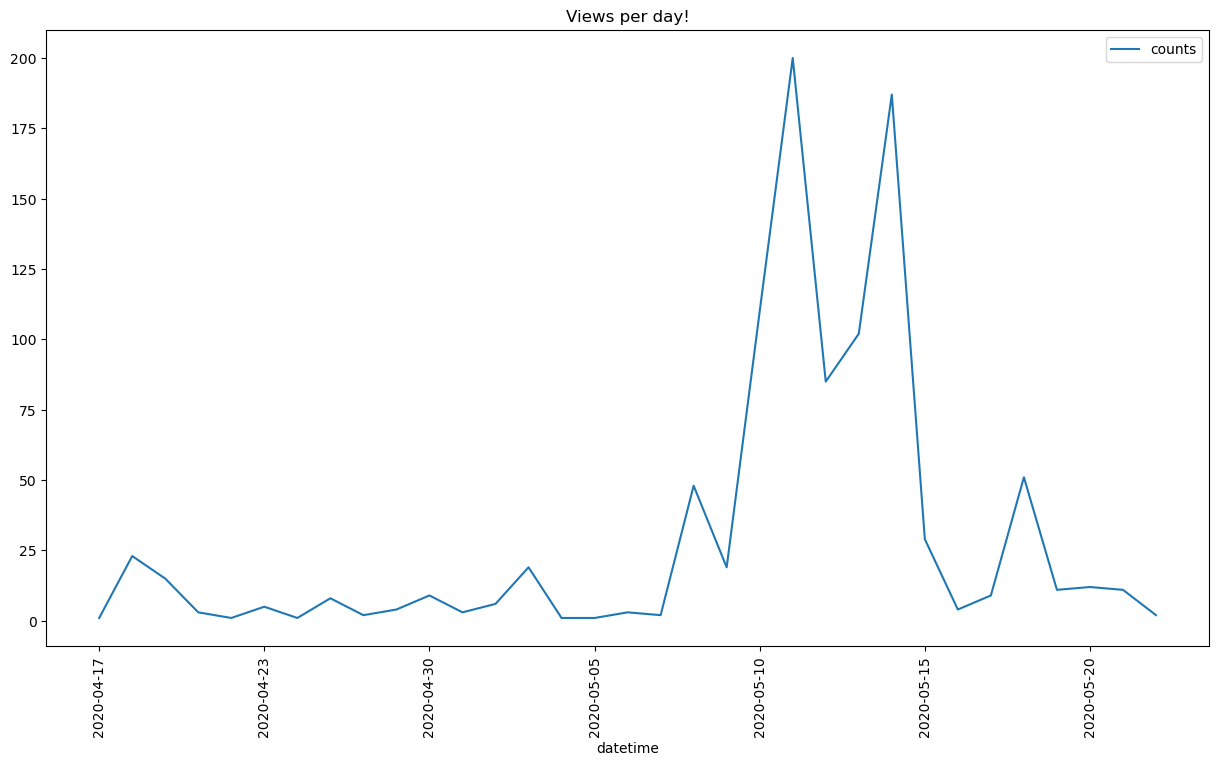

In [84]:
plt = view_counts.plot(title='Views per day!', figsize=(15, 8), rot=90)

In [85]:
conn.close()